In [1]:
import scanpy
import anndata
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import scvelo
import seaborn
import pandas
import sdevelo
import warnings
import cellrank
import moscot

(Working on SDEvelo 0.2.12)
2026-01-26 07:24:27


In [2]:
# Read input file
working_directory = "RNA Sequencing Data/"
adata = scanpy.read_h5ad(working_directory + "/velocity_sdevelo.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 12791 × 2000
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'latent_time', 'sde_velocity_self_transition', 'manual_root', 'manual_end', 'sde_velocity_pseudotime'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_sigma_1', 'fit_sigma_2'
    uns: 'log1p', 'neighbors', 'pca', 'sample_colors', 'sde_velocity_graph', 'sde_velocity_graph_neg', 'sde_velocity_params'
    obsm: 'X_fdl', 'X_pca', 'X_umap', 'sde_velocity_fdl'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'pred_s', 'pred_u', 'sde_velocity', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'


In [3]:
# Suppress warnings

warnings.simplefilter("ignore", category=UserWarning)

In [5]:
# Create velocity kernel

velocity_kernel = cellrank.kernels.VelocityKernel(adata, vkey="sde_velocity")
velocity_kernel.compute_transition_matrix()

  0%|          | 0/12791 [00:00<?, ?cell/s]

  0%|          | 0/12791 [00:00<?, ?cell/s]

VelocityKernel[n=12791, model='deterministic', similarity='correlation', softmax_scale=6.344]

In [6]:
# Create kernel based on latent time

latent_time_kernel = cellrank.kernels.PseudotimeKernel(adata, time_key = "latent_time")
latent_time_kernel.compute_transition_matrix()

  0%|          | 0/12791 [00:00<?, ?cell/s]

PseudotimeKernel[n=12791, dnorm=False, scheme='hard', frac_to_keep=0.3]

In [7]:
# Combine kernels

combined_kernel = 0.5*velocity_kernel + 0.5*latent_time_kernel
combined_kernel.compute_transition_matrix()

(0.5 * VelocityKernel[n=12791, model='deterministic', similarity='correlation', softmax_scale=6.344] + 0.5 * PseudotimeKernel[n=12791, dnorm=False, scheme='hard', frac_to_keep=0.3])

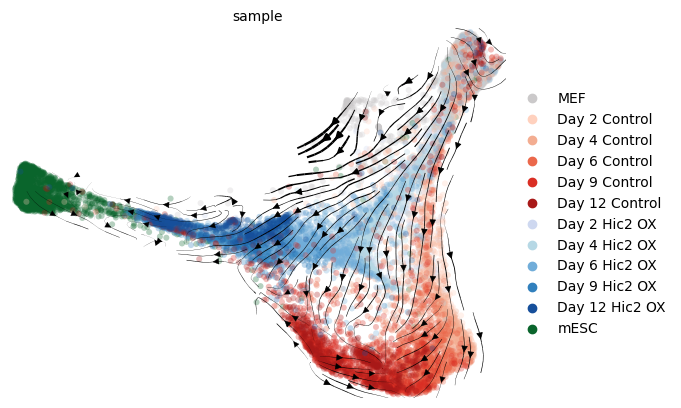

In [8]:
# Plot transition matrix
combined_kernel.plot_projection(basis="fdl", color="sample", legend_loc="right margin")

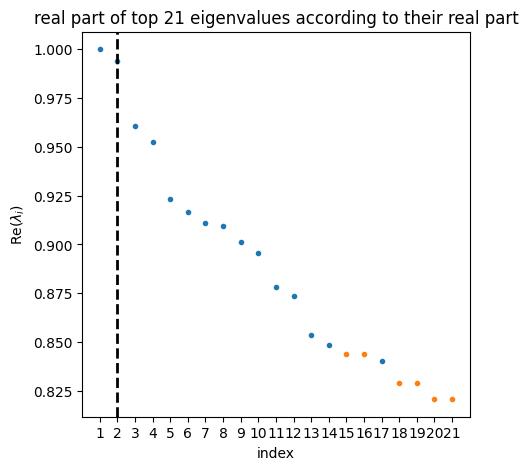

In [9]:
# More advanced estimator

estimator = cellrank.estimators.GPCCA(combined_kernel)
estimator.compute_schur()
estimator.plot_spectrum(real_only=True)

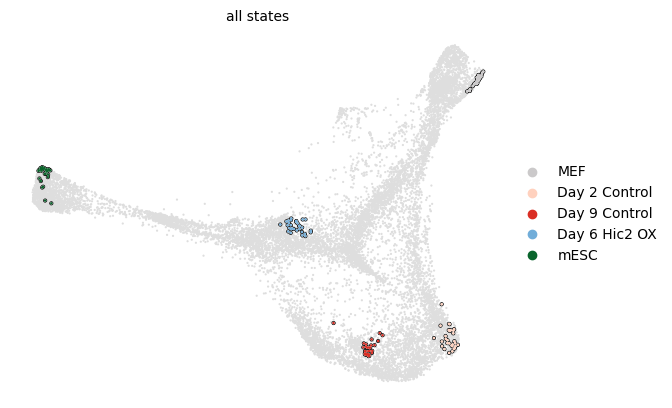

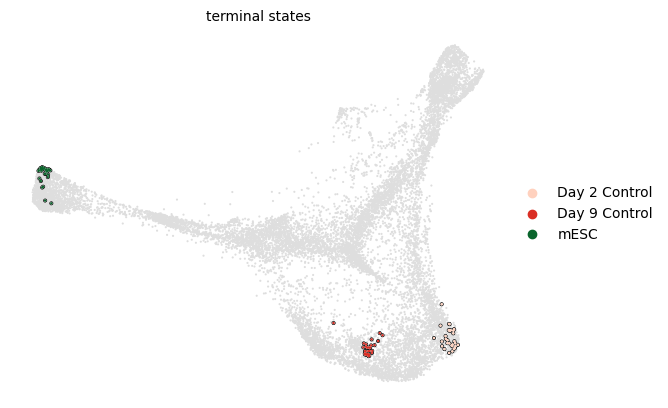

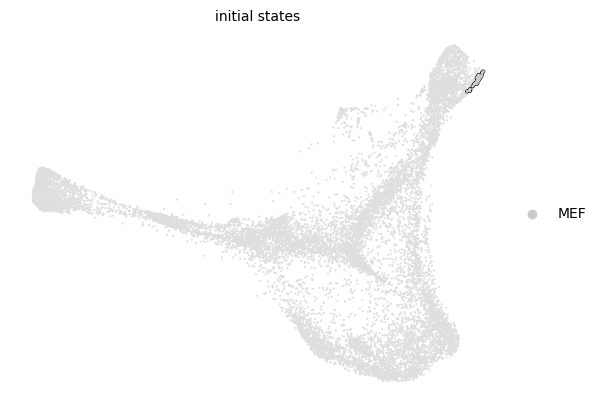

In [29]:
# Cluster

estimator.compute_macrostates(n_states=5, cluster_key="sample")

# Plot all macrostates
estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="fdl")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states

estimator.predict_terminal_states()
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="fdl")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states

estimator.predict_initial_states()
estimator.plot_macrostates(which="initial", legend_loc="right", basis="fdl", discrete=True)
initial_states = estimator.initial_states_memberships.names

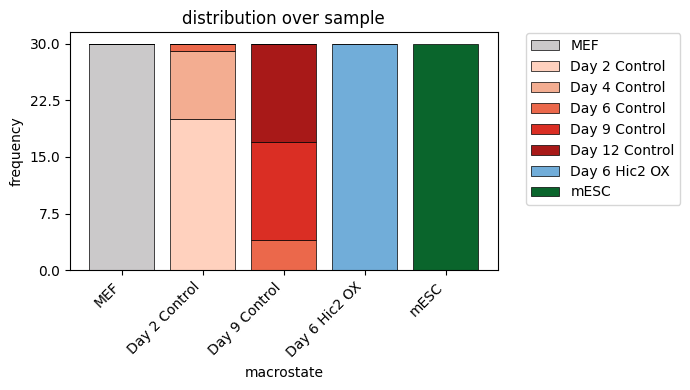

In [30]:
estimator.plot_macrostate_composition(key="sample", figsize=(7, 4))

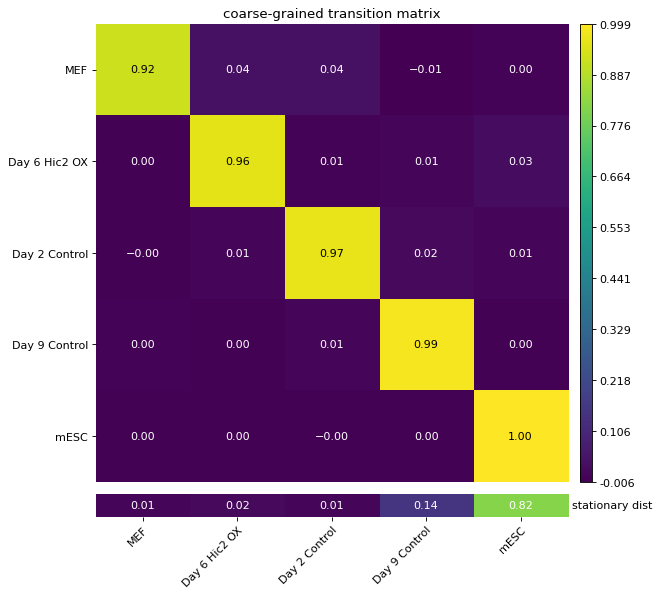

In [31]:
estimator.plot_coarse_T()

  0%|          | 0/3 [00:00<?, ?/s]

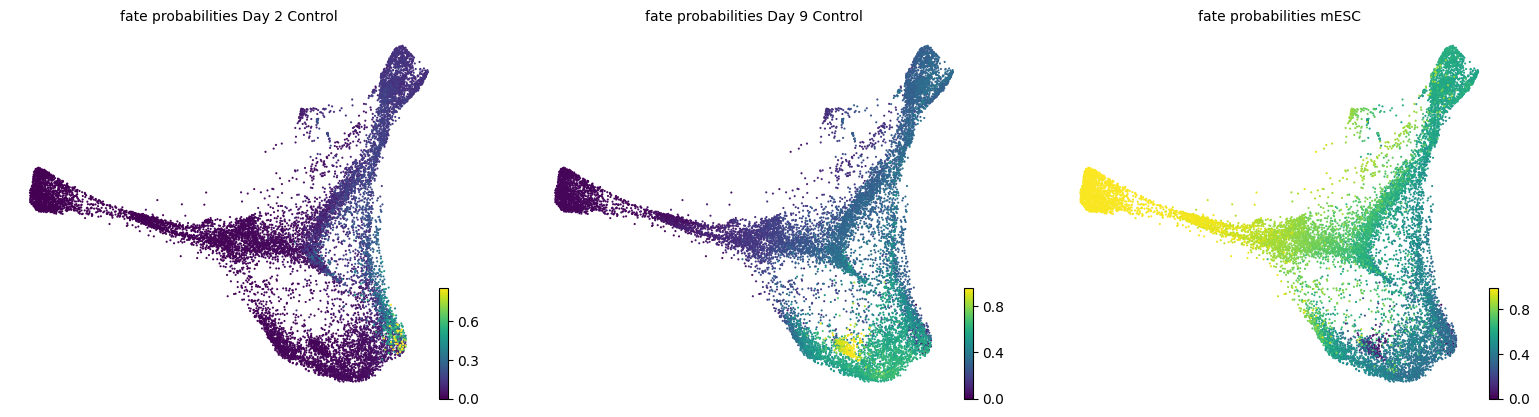

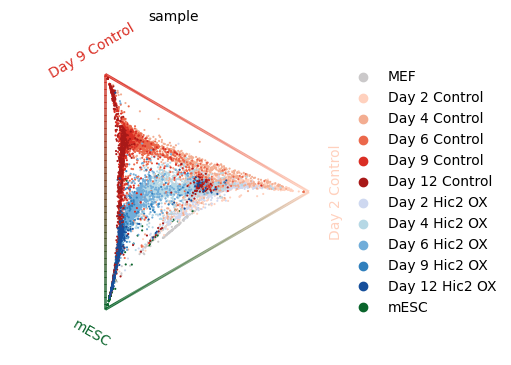

In [35]:
# Estimate fate probabilities

estimator.compute_fate_probabilities()

# Add fate probabilities to adata
for terminal_state in terminal_states:
    adata.obs[f"fate_probabilities_{terminal_state}"] = estimator.fate_probabilities[terminal_state].X.flatten()

estimator.plot_fate_probabilities(same_plot=False, basis="fdl")
cellrank.pl.circular_projection(adata, keys=["sample"], legend_loc="right")

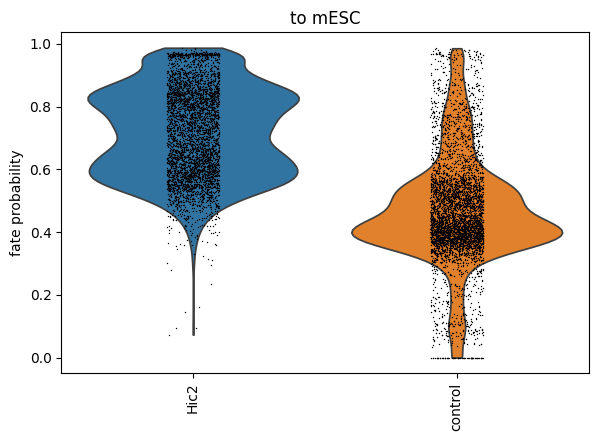

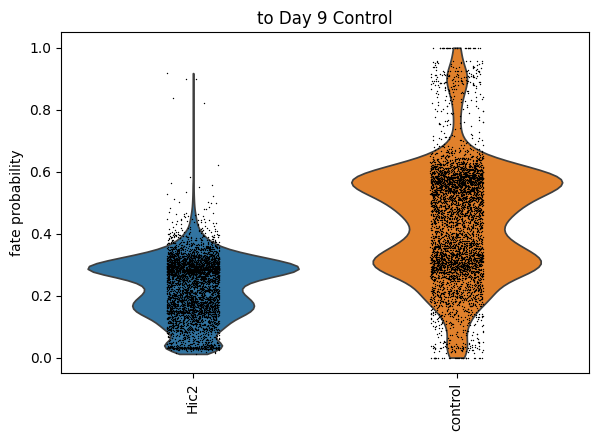

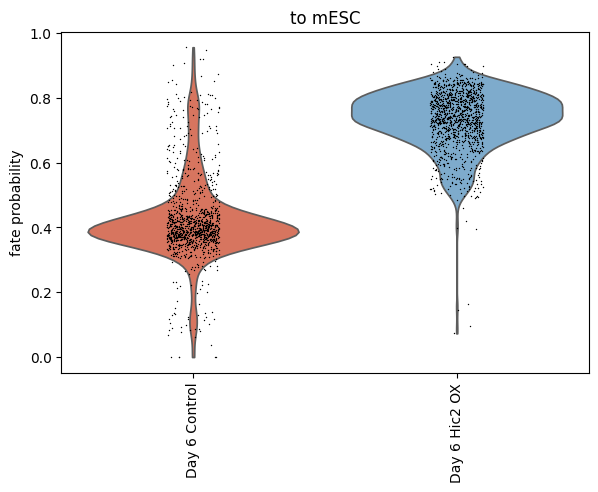

In [38]:
# Aggregate fate probabilities

cellrank.pl.aggregate_fate_probabilities(
    adata,
    mode="violin",
    lineages=["mESC"],
    cluster_key="group",
    clusters=["control", "Hic2"],
)

cellrank.pl.aggregate_fate_probabilities(
    adata,
    mode="violin",
    lineages=["Day 9 Control"],
    cluster_key="group",
    clusters=["control", "Hic2"],
)

cellrank.pl.aggregate_fate_probabilities(
    adata,
    mode="violin",
    lineages=["mESC"],
    cluster_key="sample",
    clusters=["Day 6 Control", "Day 6 Hic2 OX"],
)

In [39]:
# Find driver genes for all terminal states

reprogramming_groups = ["Hic2", "control"]

driver_df = estimator.compute_lineage_drivers(
    cluster_key="group", clusters=reprogramming_groups
)
corr_columns = [state+"_corr" for state in terminal_states]


In [40]:
# Drivers for mESCs
driver_df.sort_values("mESC_corr", ascending=False).head(20)[corr_columns]

,Day 2 Control_corr,Day 9 Control_corr,mESC_corr
gene_names,,,
Fbxo15,-0.296116,-0.499383,0.613621
Folr1,-0.292199,-0.501409,0.613377
Utf1,-0.305117,-0.486190,0.606388
Gdf3,-0.335664,-0.467017,0.605200
Mdk,-0.200506,-0.545546,0.604699
Rbpms2,-0.173431,-0.547504,0.592039
Hmgn2,-0.283651,-0.470934,0.581013
Klhl13,-0.242755,-0.491468,0.577923
Apoc1,-0.228874,-0.488778,0.568056


In [41]:
# Drivers for early control path
driver_df.sort_values("Day 2 Control_corr", ascending=False).head(20)[corr_columns]

,Day 2 Control_corr,Day 9 Control_corr,mESC_corr
gene_names,,,
Tspo,0.583247,0.030089,-0.338752
Sepw1,0.508386,-0.094820,-0.184832
Kdelr3,0.504262,0.066039,-0.329386
Ccdc109b,0.491468,0.114501,-0.366767
Fxyd5,0.486638,0.015409,-0.273785
Tgfb1,0.483740,-0.121591,-0.147260
Tpm2,0.469628,-0.084276,-0.173767
Vcan,0.466659,-0.059718,-0.194585
Ccnd2,0.464708,0.337667,-0.556076


In [43]:
# Drivers for late control path
driver_df.sort_values("Day 9 Control_corr", ascending=False).head(20)[corr_columns]

,Day 2 Control_corr,Day 9 Control_corr,mESC_corr
gene_names,,,
Lgals7,-0.241075,0.661738,-0.475014
Cd24a,0.159204,0.629983,-0.659703
Lmo1,0.033668,0.598609,-0.564064
Dkkl1,-0.249909,0.584891,-0.400194
Crb3,-0.286043,0.583245,-0.379405
Lad1,-0.167408,0.573952,-0.434250
Aldh3a1,-0.328029,0.563668,-0.339146
Krt8,-0.378639,0.563542,-0.312009
Rtn4r,0.111740,0.551394,-0.562661


In [42]:
# How specific genes correlate with terminal states
genes_of_interest = ["Krtdap", "Krt8", "Krt14", "Nanog", "Tet1", "Cdh1"]
driver_df.loc[genes_of_interest, corr_columns]

,Day 2 Control_corr,Day 9 Control_corr,mESC_corr
gene_names,,,
Krtdap,-0.238821,0.162393,-0.020677
Krt8,-0.378639,0.563542,-0.312009
Krt14,0.062359,0.332969,-0.337038
Nanog,-0.214237,-0.233733,0.327571
Tet1,-0.232715,-0.405862,0.494465
Cdh1,-0.303717,0.415080,-0.216563


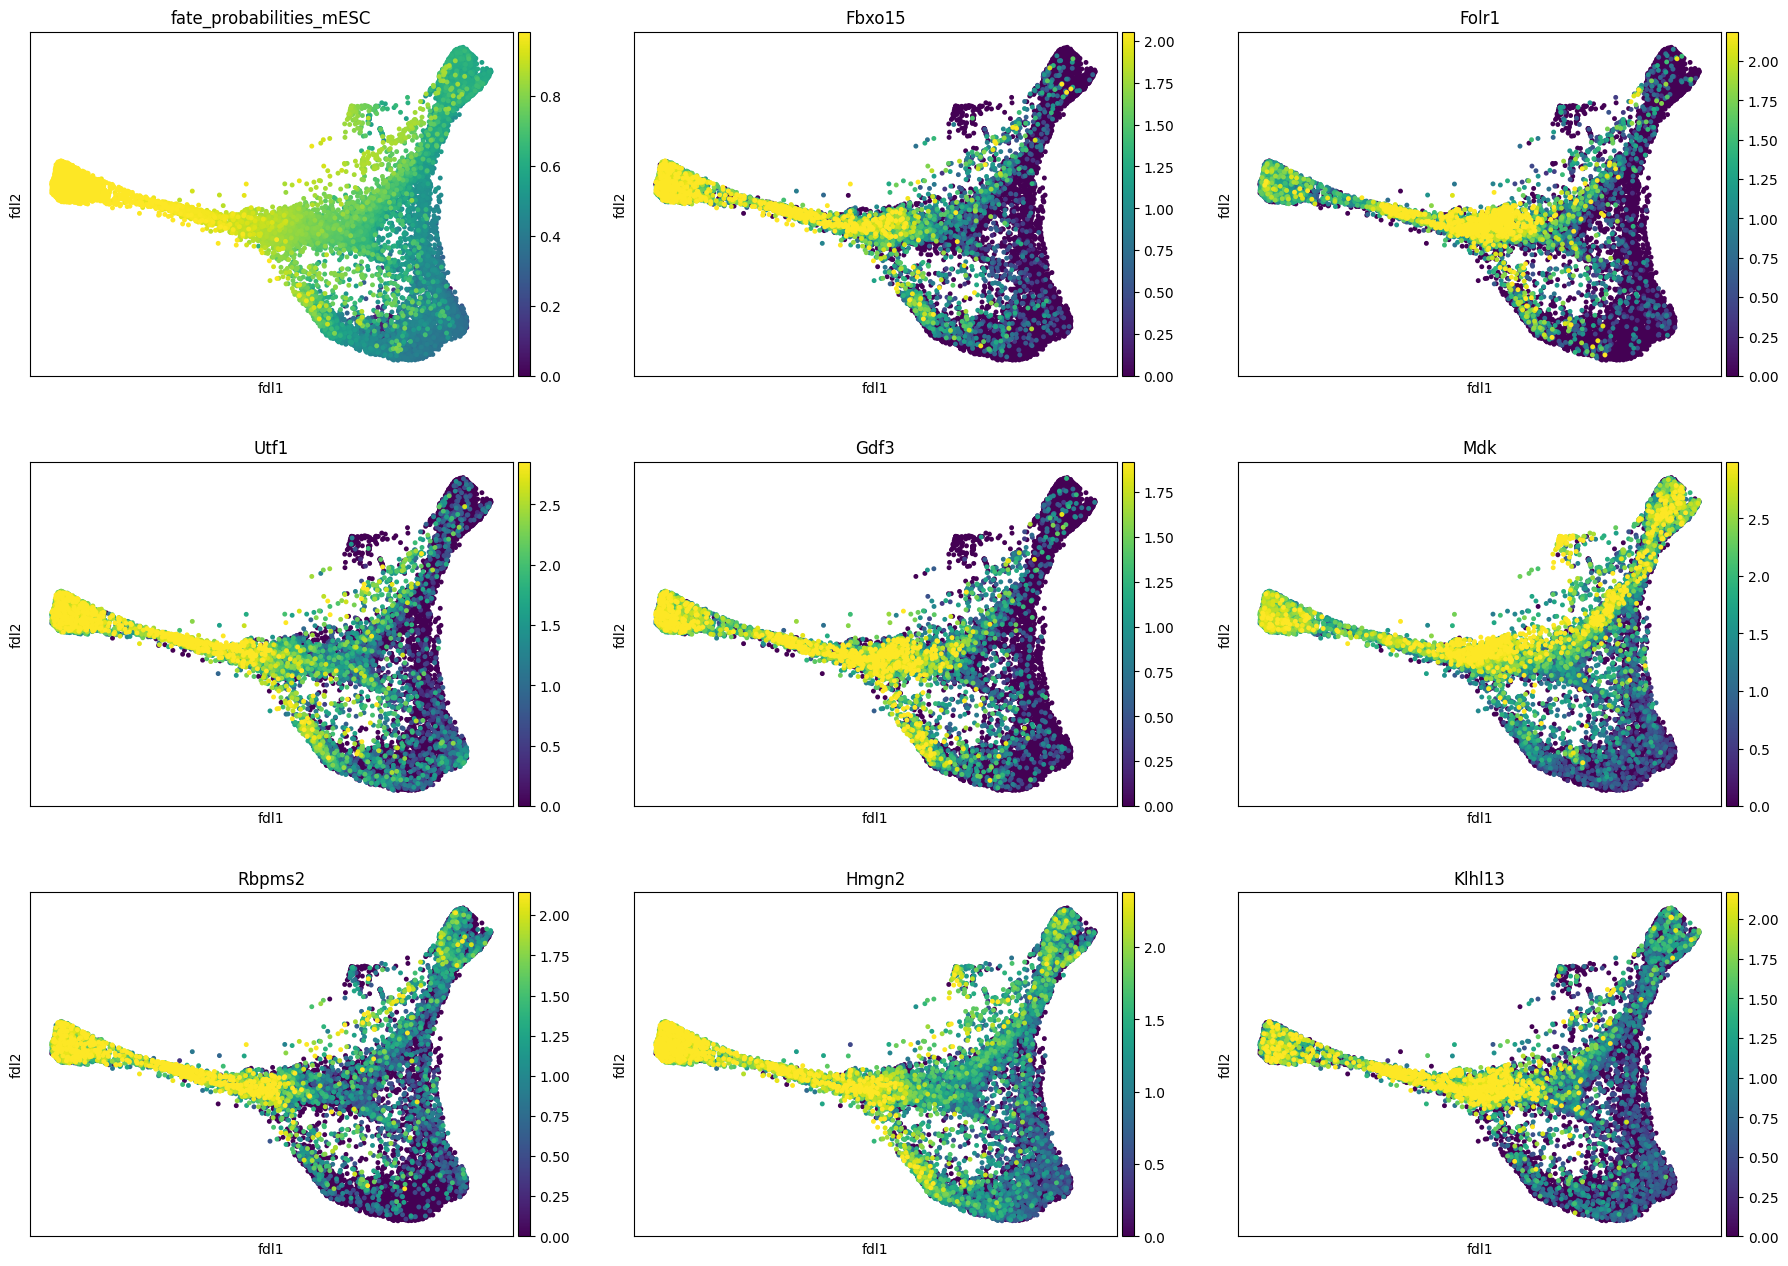

In [45]:
# Visualize driver genes for the stem cell path

terminal_state = "mESC"
scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=[f"fate_probabilities_{terminal_state}"] + list(driver_df.sort_values(f"{terminal_state}_corr", ascending=False).index[:8]),
    color_map="viridis",
    s=50,
    ncols=3,
    vmax="p96",
)

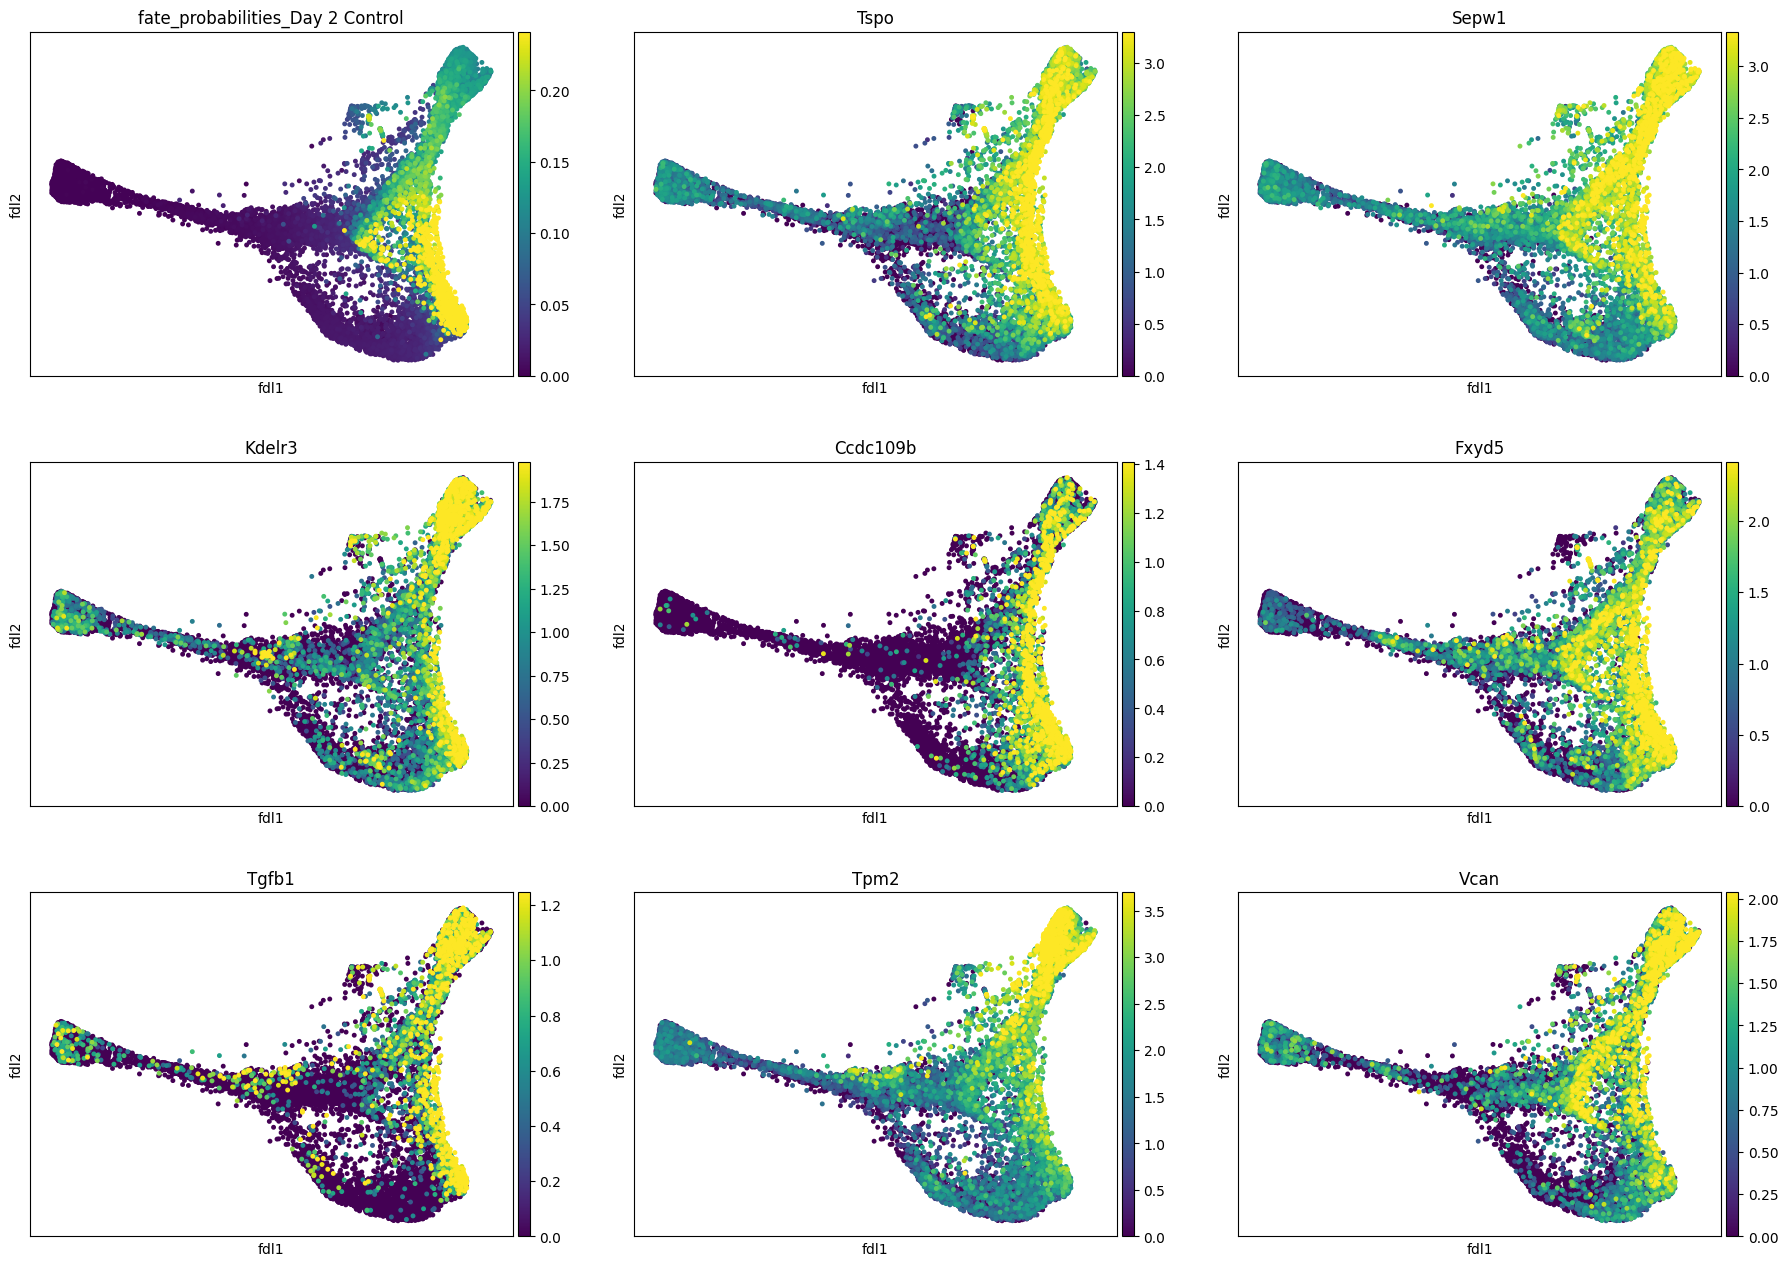

In [ ]:
# Visualize driver genes for the early control path

terminal_state = "Day 2 Control"
scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=[f"fate_probabilities_{terminal_state}"] + list(driver_df.sort_values(f"{terminal_state}_corr", ascending=False).index[:8]),
    color_map="viridis",
    s=50,
    ncols=3,
    vmax="p96",
)

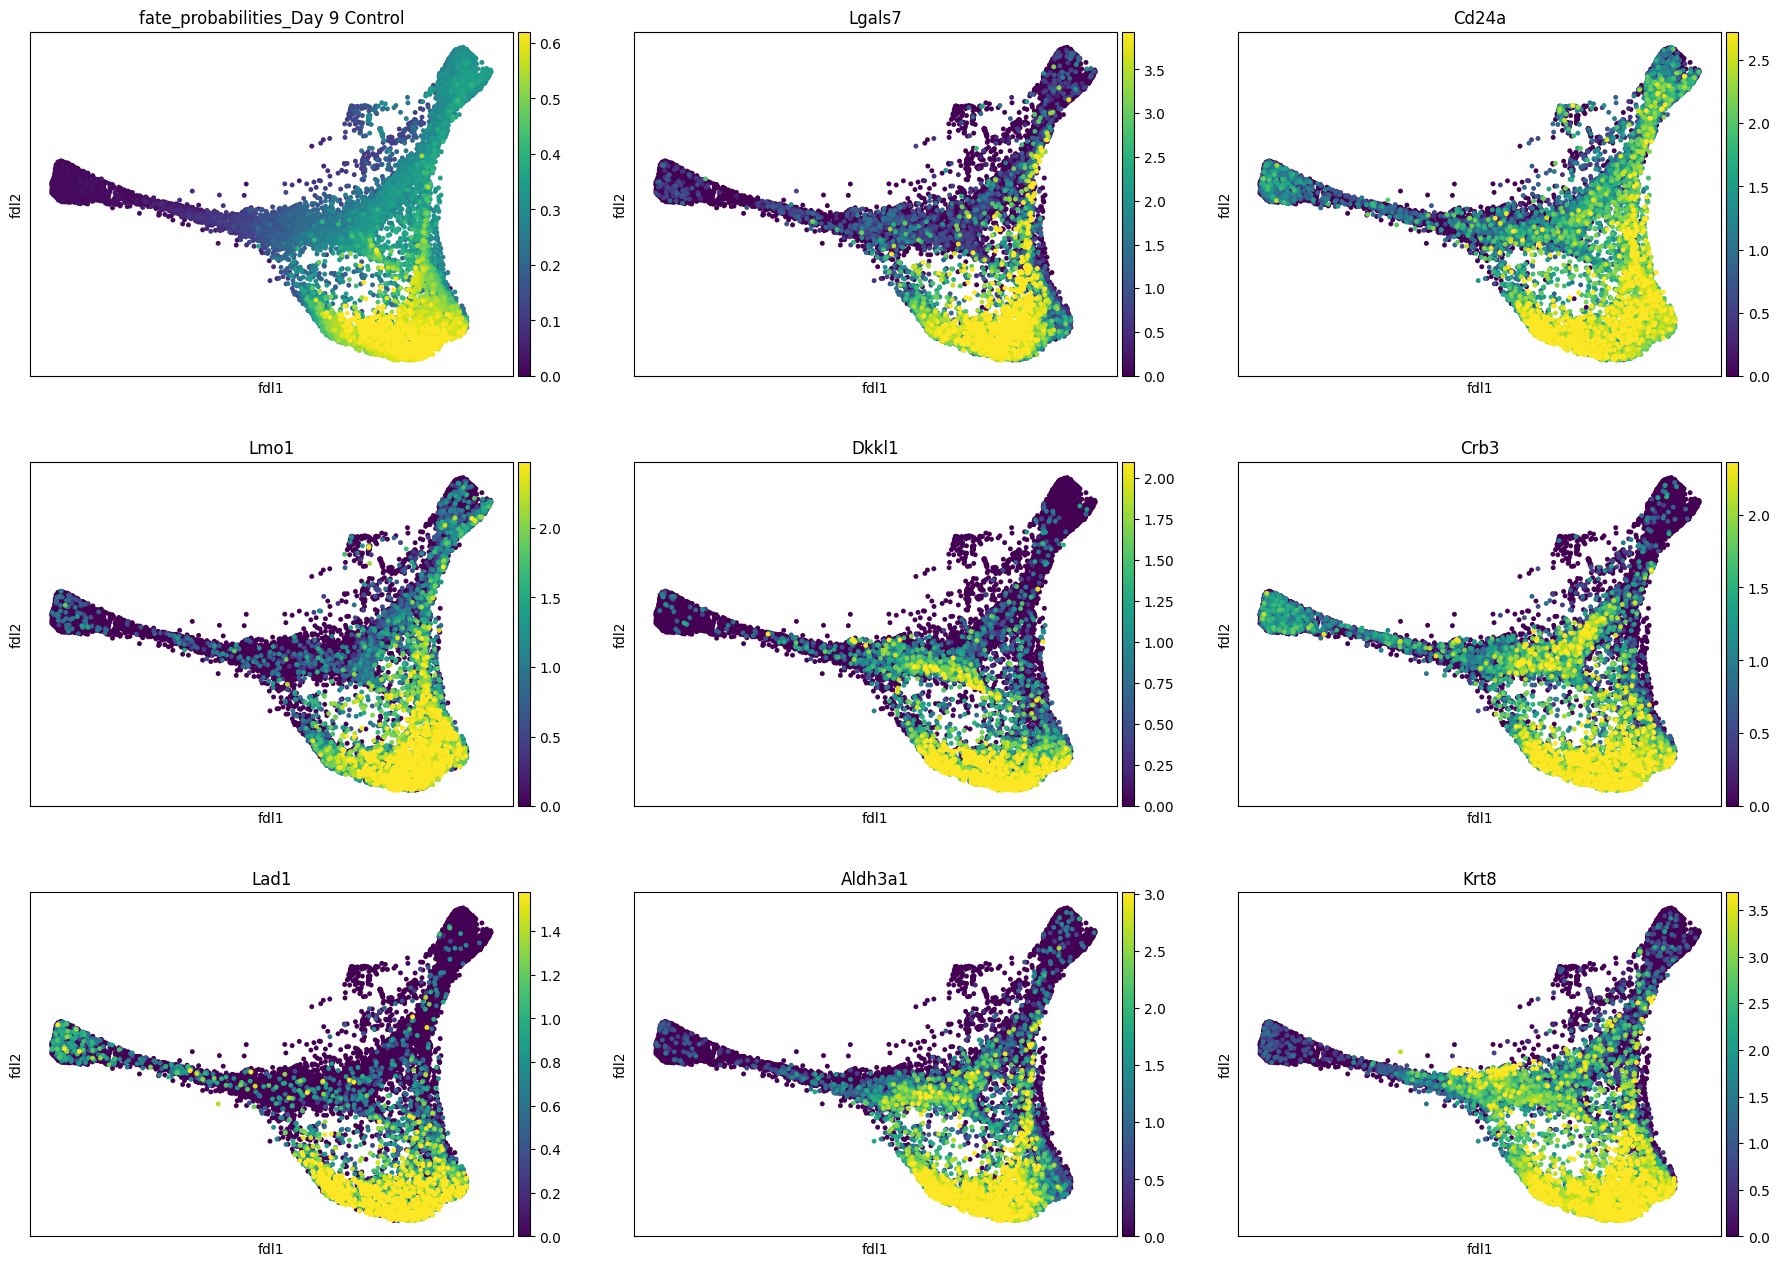

In [47]:
# Visualize driver genes for the late control path

terminal_state = "Day 9 Control"
scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=[f"fate_probabilities_{terminal_state}"] + list(driver_df.sort_values(f"{terminal_state}_corr", ascending=False).index[:8]),
    color_map="viridis",
    s=50,
    ncols=3,
    vmax="p96",
)

In [48]:
# Gene expression over time

# Create model
model = cellrank.models.GAMR(adata, n_knots=6, smoothing_penalty=10.0) # GAMR can be used instead to have the R model

  0%|          | 0/7 [00:00<?, ?gene/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


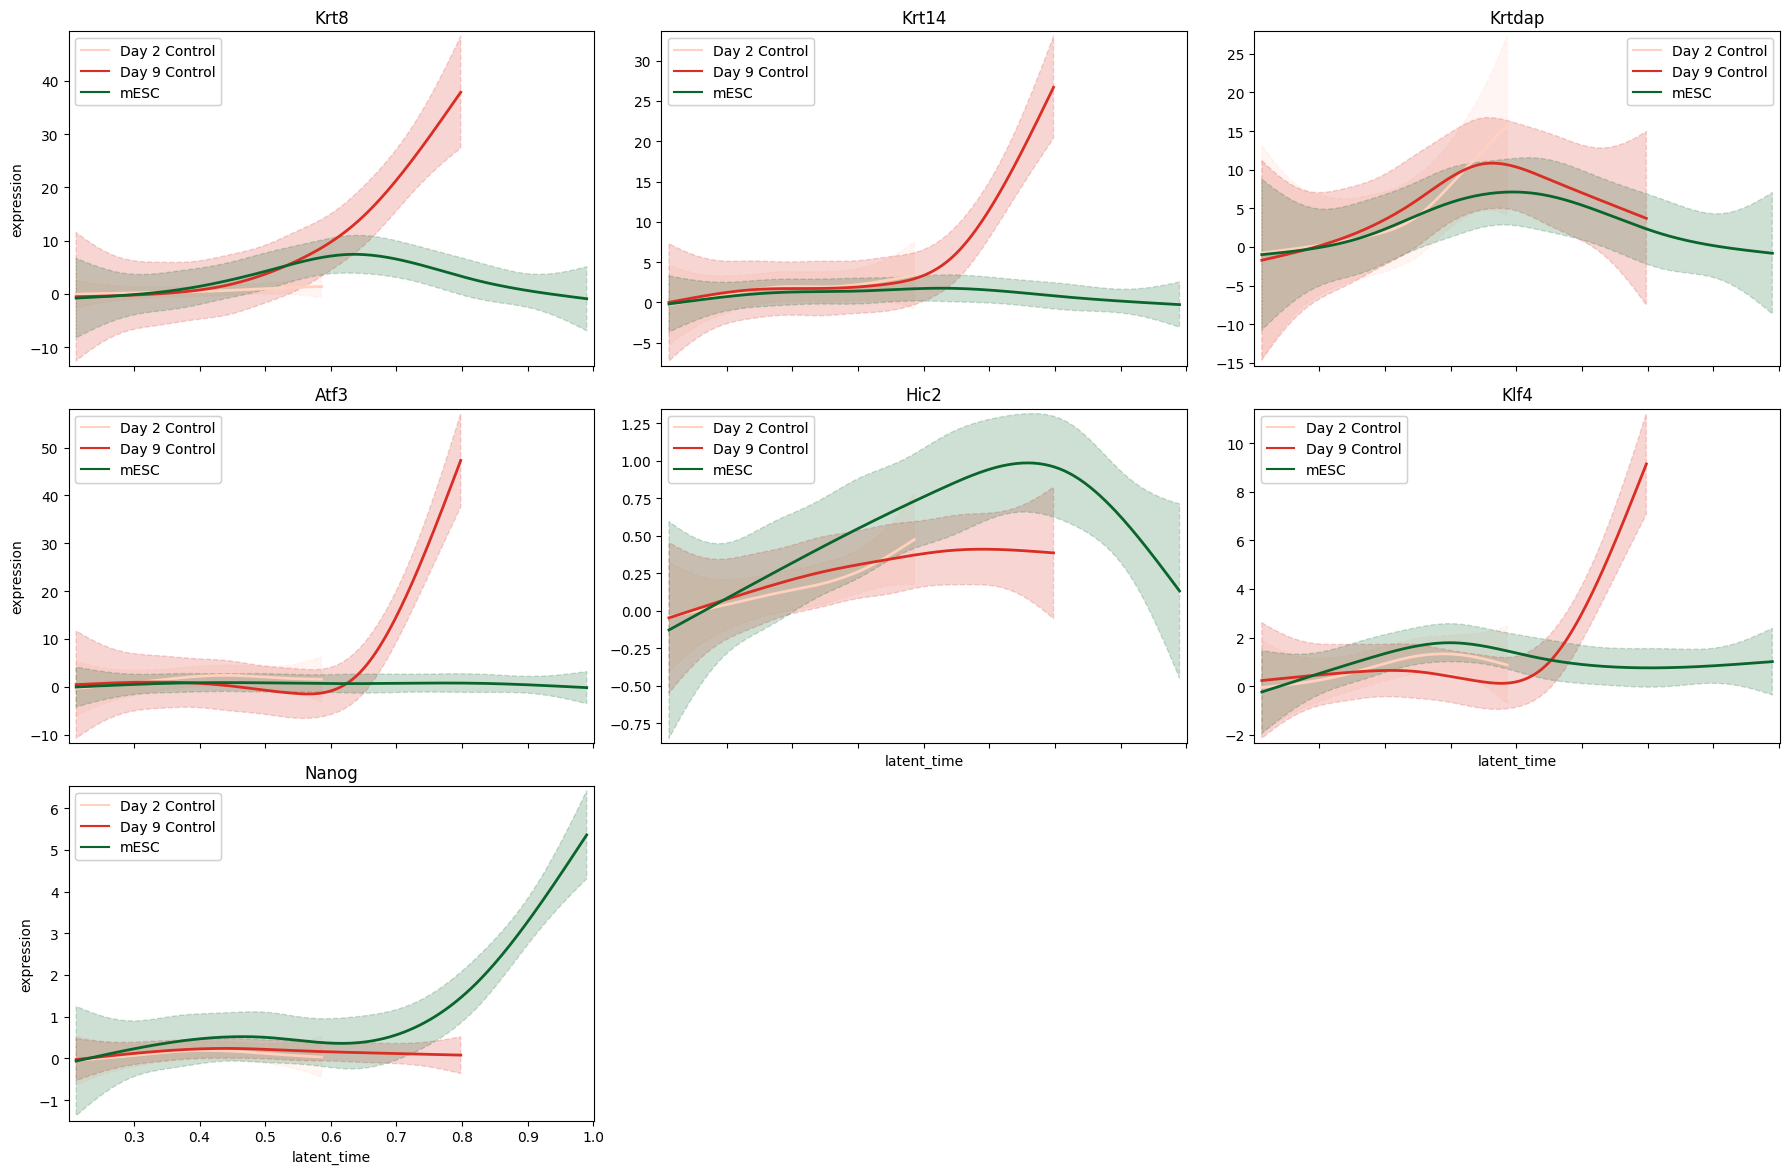

In [49]:
trend_genes = ["Krt8", "Krt14", "Krtdap", "Atf3", "Hic2", "Klf4", "Nanog"]
reprogramming_group_indices = (adata.obs["group"] == "control") | (adata.obs["group"] == "Hic2")
cellrank.pl.gene_trends(
    adata[reprogramming_group_indices],
    model=model,
    genes=trend_genes,
    data_key="spliced",
    same_plot=True,
    ncols=3,
    time_key="latent_time",
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)


  0%|          | 0/20 [00:00<?, ?gene/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


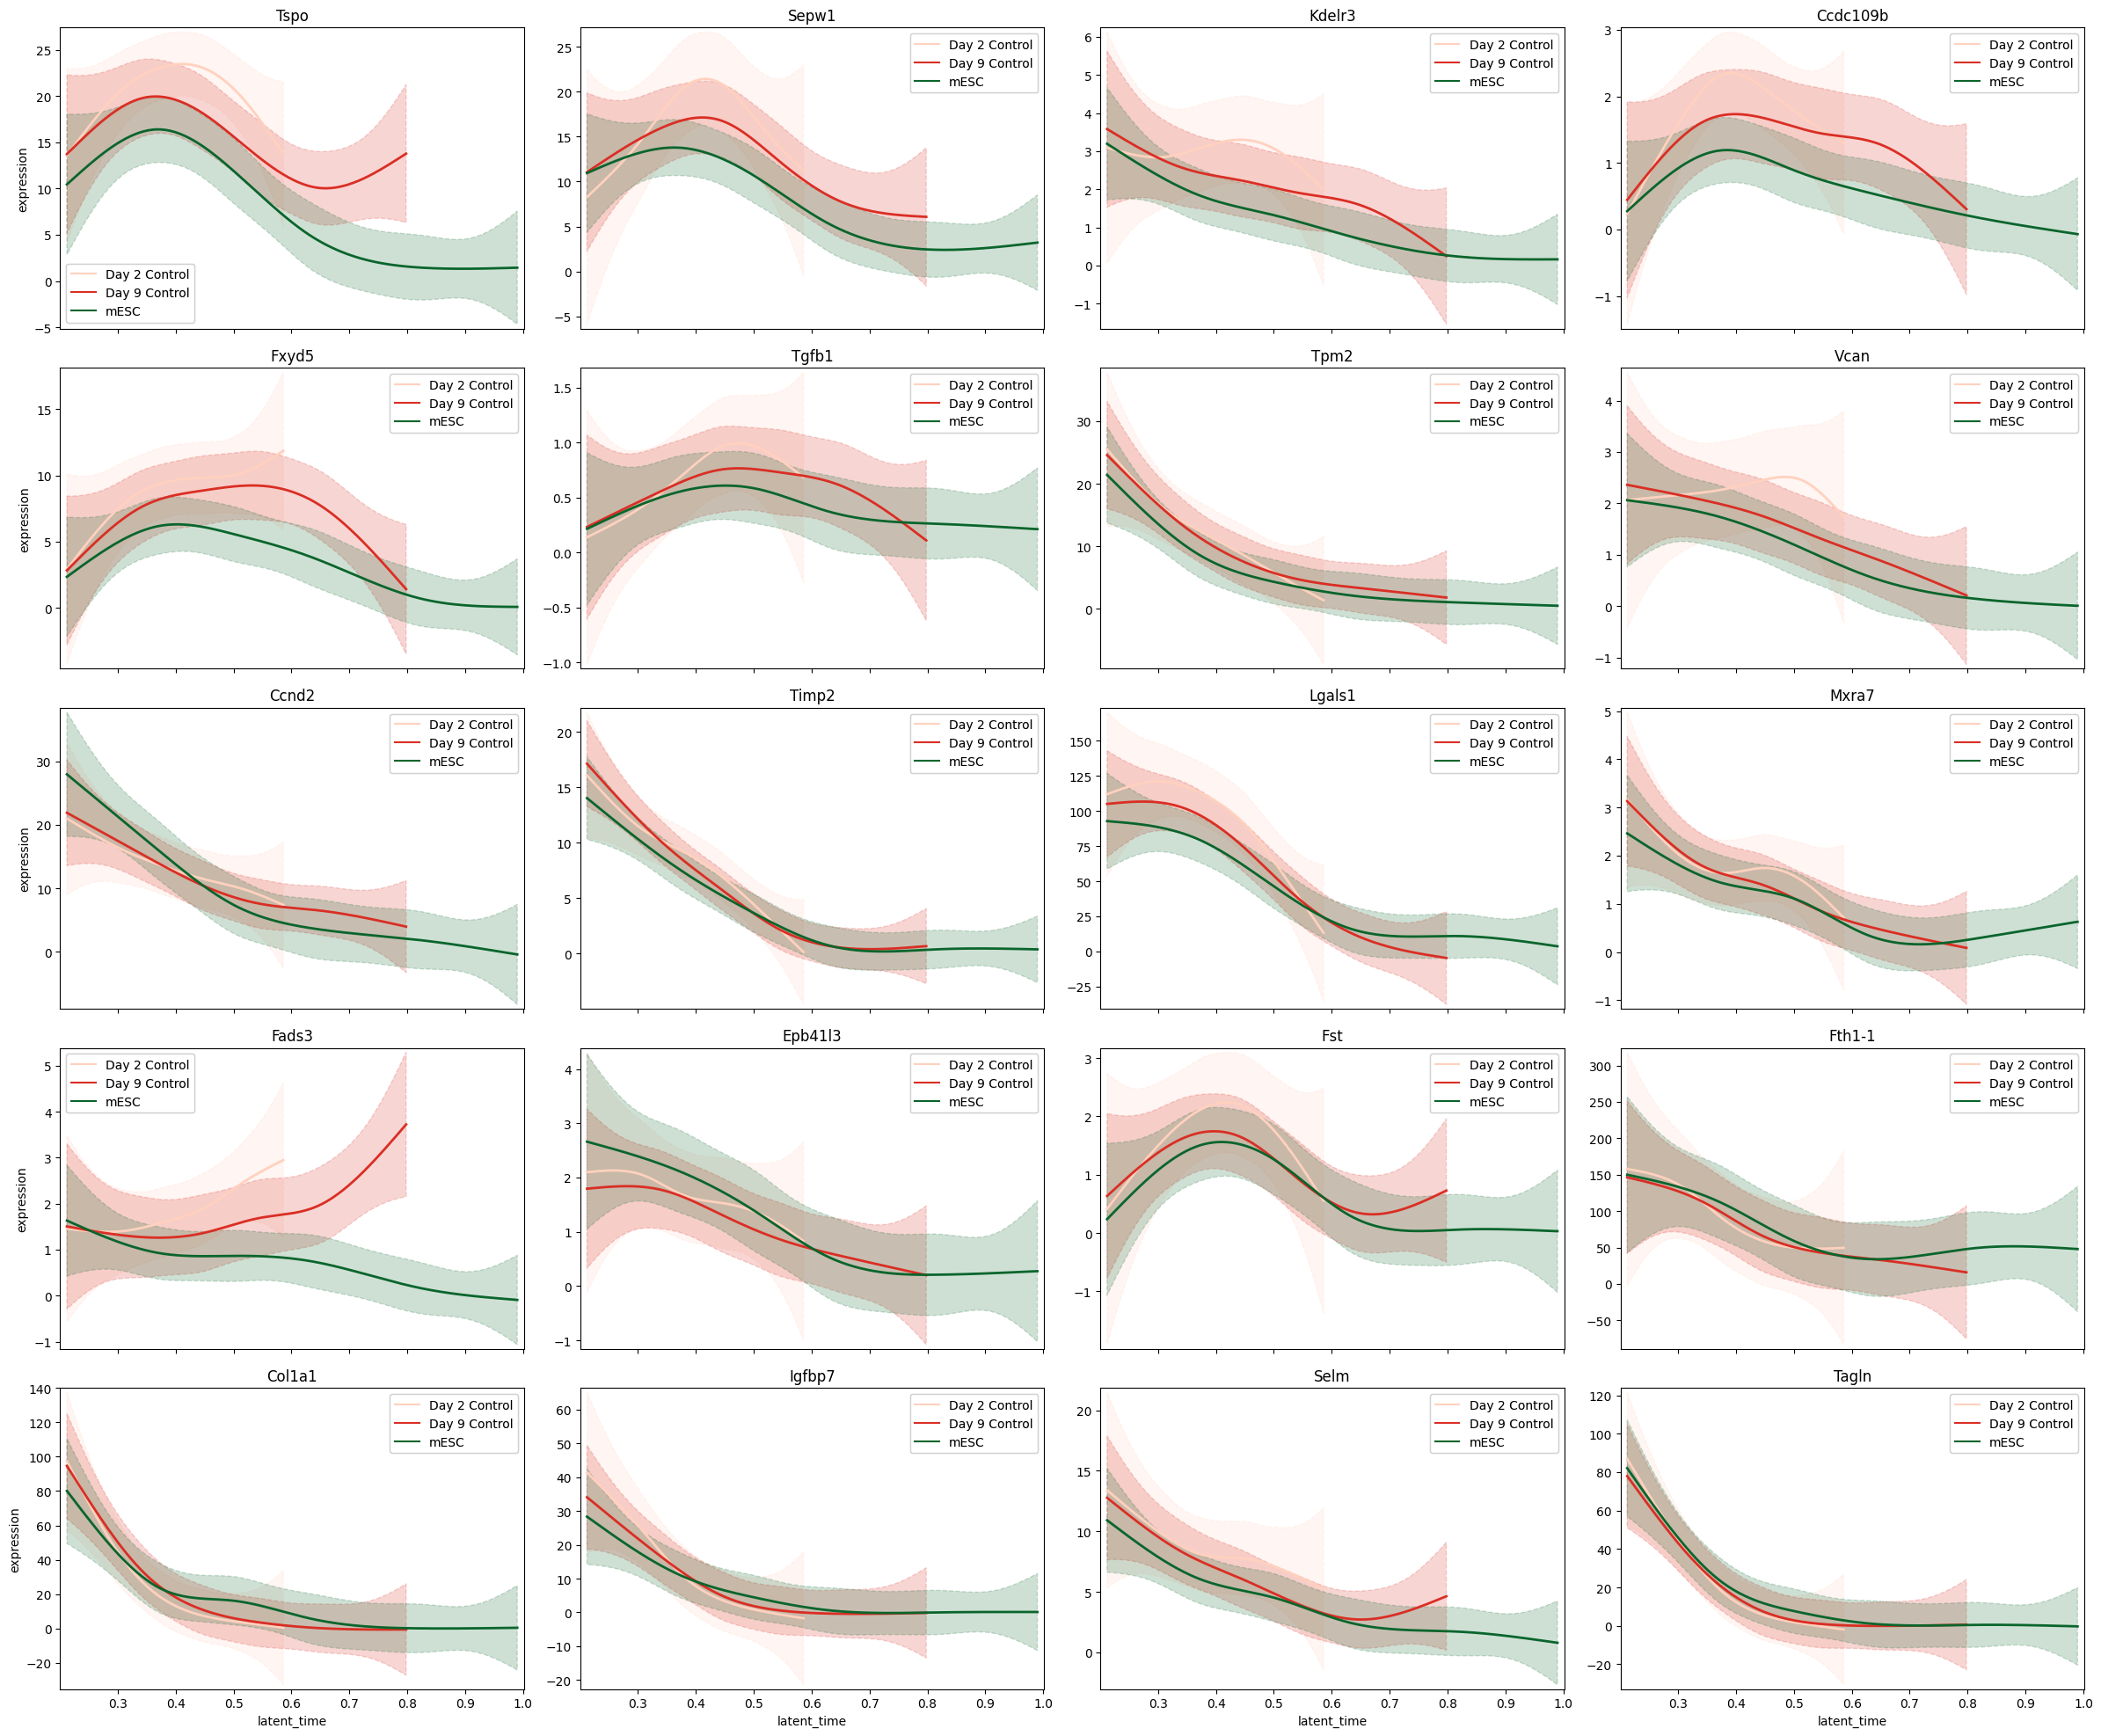

In [50]:
# The 20 strongest drivers of early control
cellrank.pl.gene_trends(
    adata[reprogramming_group_indices],
    model=model,
    genes=driver_df.sort_values(f"Day 2 Control_corr", ascending=False).head(20).index,
    data_key="spliced",
    same_plot=True,
    ncols=4,
    time_key="latent_time",
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)
